<a href="https://colab.research.google.com/github/yaokoolivier/hacbio/blob/main/olivier_noia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Importation des librairies**

In [30]:
# On importe pandas : bibliothèque pour lire et manipuler des tableaux de données
import pandas as pd

# On importe numpy : bibliothèque pour faire des calculs mathématiques sur des tableaux de nombres
import numpy as np

# On importe matplotlib : bibliothèque pour créer des graphiques et visualisations
import matplotlib.pyplot as plt

# On importe seaborn : bibliothèque de graphiques plus esthétiques, basée sur matplotlib
import seaborn as sns

# On importe RandomForestClassifier : notre algorithme principal de classification
from sklearn.ensemble import RandomForestClassifier

# On importe train_test_split : fonction qui divise nos données en deux parties
from sklearn.model_selection import train_test_split

# On importe les métriques d'évaluation :
from sklearn.metrics import classification_report, confusion_matrix

# **2. Chargement des données**

In [31]:
# On lit le fichier CSV d'entraînement et on le stocke dans la variable train
train = pd.read_csv("train_file.csv")

# On lit le fichier CSV de test de la même façon et on le stocke dans test
test = pd.read_csv("test_file.csv")

# On affiche la taille du fichier train
print(f"Train : {train.shape[0]} lignes, {train.shape[1]} colonnes")

# On affiche la taille du fichier test de la même façon
print(f"Test  : {test.shape[0]} lignes, {test.shape[1]} colonnes")

Train : 5600 lignes, 22 colonnes
Test  : 2400 lignes, 21 colonnes


# **3. Exploration des données**

=== Aperçu du fichier train ===
     id     col_0      col_1      col_2      col_3      col_4     col_5  \
0  1035  2.440291  18.803669  58.516966   9.036167  50.743645  2.616749   
1  4114  2.169448  24.294184  67.503844  11.834599  45.908778  2.011304   
2   929  3.023596  10.293279  65.193868   9.252690  32.051982  2.968073   
3  2642  2.767535  18.945972  65.554293  11.736898  48.732568  3.378123   
4  7206  3.101379  13.828258  84.972532  11.598183  48.987365  3.345562   

       col_6     col_7     col_8  ...    col_11     col_12    col_13  \
0  10.795447  7.660446  4.668714  ...  4.902706  32.456142  7.968399   
1  26.907888  6.340541  3.395222  ...  4.696788  54.560997  7.041915   
2  15.973128  3.868862  5.101278  ...  3.778641  38.996286  4.508824   
3  15.704830  5.978061  3.454681  ...  4.933742  63.196446  5.938648   
4  18.102956  4.185259  3.708816  ...  3.388722  61.371441  6.734750   

     col_14    col_15    col_16    col_17     col_18     col_19  target  
0  3.09137

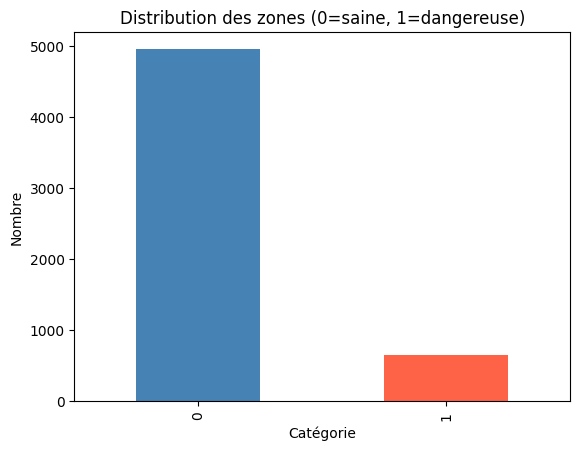

In [32]:
# On affiche un titre pour s'y retrouver dans la sortie
print("=== Aperçu du fichier train ===")

print(train.head())

# On affiche un titre pour la section suivante
print("\n=== Distribution de la cible ===")

# On compte combien de fois chaque valeur apparaît dans la colonne 'target'
print(train['target'].value_counts())

# On crée un graphique en barres à partir du comptage des valeurs de 'target'
train['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])

# On ajoute un titre au graphique
plt.title("Distribution des zones (0=saine, 1=dangereuse)")

# On ajoute un label sur l'axe horizontal X
plt.xlabel("Catégorie")

# On ajoute un label sur l'axe vertical Y
plt.ylabel("Nombre")

# On affiche le graphique à l'écran
plt.show()

# **4. Préparation des données**

In [33]:
# SÉPARATION DES FEATURES ET DE LA CIBLE

# On sélectionne toutes les colonnes SAUF 'id' et 'target'
X = train.drop(columns=['id', 'target'], axis=1)

# On sélectionne uniquement la colonne 'target'
y = train['target']

# On affiche la forme de X pour vérifier
print(f" Features X : {X.shape[0]} lignes, {X.shape[1]} colonnes")

# On affiche la forme de y pour vérifier
print(f" Cible y    : {y.shape[0]} valeurs")


#  DIVISION EN ENSEMBLE D'ENTRAÎNEMENT ET DE VALIDATION

# On divise X et y en deux parties :
# 80% des données → pour entraîner le modèle
# 20% des données → pour évaluer le modèle
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# On affiche les tailles pour vérifier le découpage
print(f"\n Entraînement : {X_train.shape[0]} exemples")
print(f"Validation   : {X_val.shape[0]} exemples")

 Features X : 5600 lignes, 20 colonnes
 Cible y    : 5600 valeurs

 Entraînement : 4480 exemples
Validation   : 1120 exemples


# **5. Entraînement du modèle**

In [34]:
# CRÉATION DU MODÈLE

# On crée un modèle Random Forest
# random_state=42 : pour avoir les mêmes résultats à chaque exécution
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# ENTRAÎNEMENT

# On entraîne le modèle avec nos données d'entraînement
model.fit(X_train, y_train)

#  PRÉDICTIONS SUR LA VALIDATION

# On demande au modèle de prédire les targets sur les données de validation
y_pred = model.predict(X_val)

# On affiche un aperçu des premières prédictions
print(f"\nAperçu des prédictions : {y_pred[:10]}")
print(f"Vraies valeurs        : {y_val[:10].values}")


Aperçu des prédictions : [0 0 0 0 0 0 0 0 0 1]
Vraies valeurs        : [0 0 0 0 0 0 0 0 0 1]


# **6a. Évaluation du modèle**

Rapport de classification
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       994
           1       1.00      0.06      0.12       126

    accuracy                           0.89      1120
   macro avg       0.95      0.53      0.53      1120
weighted avg       0.91      0.89      0.85      1120



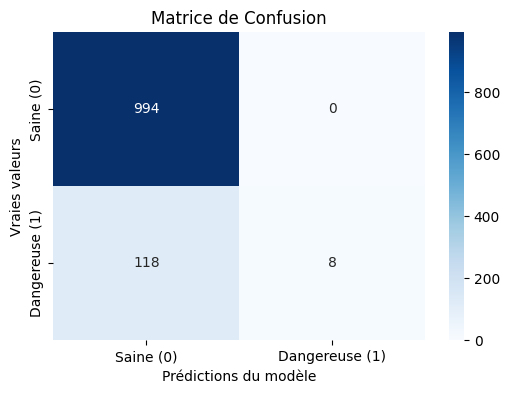


 Précision  : 100.00%
 Rappel     : 6.35%
 F1-score   : 11.94%

 Interprétation du F1-score :
Modèle faible - le seuil doit être ajusté !


In [56]:
# RAPPORT DE CLASSIFICATION

# On affiche le rapport complet d'évaluation du modèle
# Ce rapport contient 3 métriques importantes pour chaque classe (0 et 1) :

# - Précision : parmi les zones prédites dangereuses, combien le sont vraiment ?
#   Précision = VP / (VP + FP)

# - Rappel : parmi les vraies zones dangereuses, combien on a trouvées ?
#   Rappel = VP / (VP + FN)

# - F1-score : note unique qui combine précision et rappel
#   F1 = 2 × (Précision × Rappel) / (Précision + Rappel)
#   Plus le F1-score est élevé, meilleur est le modèle

# y_val : les vraies valeurs, y_pred : les valeurs prédites par le modèle
print("Rapport de classification")
print(classification_report(y_val, y_pred))


#  MATRICE DE CONFUSION

# La matrice de confusion est un tableau 2x2 qui montre :
# - Vrais Négatifs  (VN) : zones saines bien prédites comme saines
# - Faux Positifs   (FP) : zones saines mal prédites comme dangereuses
# - Faux Négatifs   (FN) : zones dangereuses mal prédites comme saines
# - Vrais Positifs  (VP) : zones dangereuses bien prédites comme dangereuses
cm = confusion_matrix(y_val, y_pred)

# On crée une figure de taille 6x4 pixels pour afficher la matrice
plt.figure(figsize=(6, 4))

# On dessine la matrice de confusion sous forme de carte de chaleur (heatmap)
# annot=True : affiche les nombres dans chaque case
# fmt='d'    : affiche les nombres en entier (pas de décimales)
# cmap       : couleur bleue pour la carte
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saine (0)', 'Dangereuse (1)'],
            yticklabels=['Saine (0)', 'Dangereuse (1)'])

# On ajoute les labels et le titre du graphique
plt.title("Matrice de Confusion")
plt.xlabel("Prédictions du modèle")
plt.ylabel("Vraies valeurs")

# On affiche le graphique
plt.show()


# CALCUL MANUEL DU F1-SCORE

# On extrait les valeurs de la matrice de confusion
# cm[0][0] = VN, cm[0][1] = FP, cm[1][0] = FN, cm[1][1] = VP
VN = cm[0][0]  # Zones saines bien prédites
FP = cm[0][1]  # Zones saines mal prédites comme dangereuses
FN = cm[1][0]  # Zones dangereuses ratées
VP = cm[1][1]  # Zones dangereuses bien trouvées

# On calcule la précision
# Parmi toutes les zones prédites dangereuses, combien le sont vraiment ?
precision = VP / (VP + FP)

# On calcule le rappel
# Parmi toutes les vraies zones dangereuses, combien on a trouvées ?
rappel = VP / (VP + FN)

# On calcule le F1-score
# C'est la moyenne harmonique entre précision et rappel
# Une seule note qui résume la qualité globale du modèle
# Plus ce score est élevé, plus le modèle est bon !
f1 = 2 * (precision * rappel) / (precision + rappel)

# On affiche les résultats
print(f"\n Précision  : {precision:.2%}")
print(f" Rappel     : {rappel:.2%}")
print(f" F1-score   : {f1:.2%}")

# On interprète le F1-score automatiquement
print("\n Interprétation du F1-score :")
if f1 >= 0.90:
    print("Excellent modèle !")
elif f1 >= 0.70:
    print("Bon modèle !")
elif f1 >= 0.50:
    print("Modèle moyen - peut être amélioré")
else:
    print("Modèle faible - le seuil doit être ajusté !")

# **6b. Modèle amélioré**

 Rapport avec seuil ajusté (0.30) 
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       994
           1       0.76      0.31      0.44       126

    accuracy                           0.91      1120
   macro avg       0.84      0.65      0.70      1120
weighted avg       0.90      0.91      0.89      1120



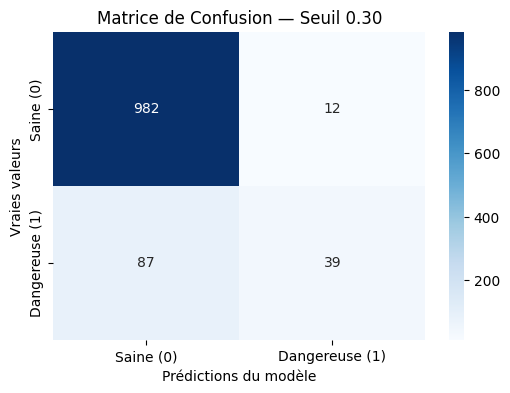

In [58]:
# PRÉDICTION AVEC PROBABILITÉS

# Au lieu de prédire directement 0 ou 1,
# on demande au modèle la PROBABILITÉ que ce soit 1
# predict_proba() retourne deux colonnes :
# colonne 0 : probabilité d'être saine
# colonne 1 : probabilité d'être dangereuse
# On prend uniquement la colonne 1 (index [:,1])
y_proba = model.predict_proba(X_val)[:, 1]

#  NOUVEAU SEUIL DE DÉCISION

# On dit : si la probabilité d'être dangereuse > 30%
# alors on prédit 1 (dangereuse)
# Avant c'était 50% → le modèle était trop strict
# Avec 30% → le modèle sera plus sensible aux zones dangereuses
seuil = 0.30
y_pred_adjusted = (y_proba >= seuil).astype(int)

#  NOUVEAU RAPPORT

# On affiche le nouveau rapport avec le seuil ajusté
print(" Rapport avec seuil ajusté (0.30) ")
print(classification_report(y_val, y_pred_adjusted))

#  NOUVELLE MATRICE DE CONFUSION

# On recalcule et affiche la nouvelle matrice de confusion
cm2 = confusion_matrix(y_val, y_pred_adjusted)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saine (0)', 'Dangereuse (1)'],
            yticklabels=['Saine (0)', 'Dangereuse (1)'])
plt.title("Matrice de Confusion — Seuil 0.30")
plt.xlabel("Prédictions du modèle")
plt.ylabel("Vraies valeurs")
plt.show()

# **6c.  Trouver le meilleur seuil automatiquement**

Recherche du meilleur seuil 

Seuil 0.10 → F1 : 36.67%
Seuil 0.11 → F1 : 38.58%
Seuil 0.12 → F1 : 40.00%
Seuil 0.13 → F1 : 41.90%
Seuil 0.14 → F1 : 42.86%
Seuil 0.15 → F1 : 43.98%
Seuil 0.16 → F1 : 45.89%
Seuil 0.17 → F1 : 47.38%
Seuil 0.18 → F1 : 48.21%
Seuil 0.19 → F1 : 49.12%
Seuil 0.20 → F1 : 50.18%
Seuil 0.21 → F1 : 49.41%
Seuil 0.22 → F1 : 50.00%
Seuil 0.23 → F1 : 50.85%
Seuil 0.24 → F1 : 51.82%
Seuil 0.25 → F1 : 53.77%
Seuil 0.26 → F1 : 53.66%
Seuil 0.27 → F1 : 53.54%
Seuil 0.28 → F1 : 49.47%
Seuil 0.29 → F1 : 48.09%
Seuil 0.30 → F1 : 44.07%
Seuil 0.31 → F1 : 43.02%
Seuil 0.32 → F1 : 41.42%
Seuil 0.33 → F1 : 40.48%
Seuil 0.34 → F1 : 40.00%
Seuil 0.35 → F1 : 35.00%
Seuil 0.36 → F1 : 29.68%
Seuil 0.37 → F1 : 26.67%
Seuil 0.38 → F1 : 25.85%
Seuil 0.39 → F1 : 24.66%
Seuil 0.40 → F1 : 20.98%
Seuil 0.41 → F1 : 20.98%
Seuil 0.42 → F1 : 18.44%
Seuil 0.43 → F1 : 17.27%
Seuil 0.44 → F1 : 17.39%
Seuil 0.45 → F1 : 17.39%
Seuil 0.46 → F1 : 17.39%
Seuil 0.47 → F1 : 17.39%
Seuil 0.48 → F1 : 16

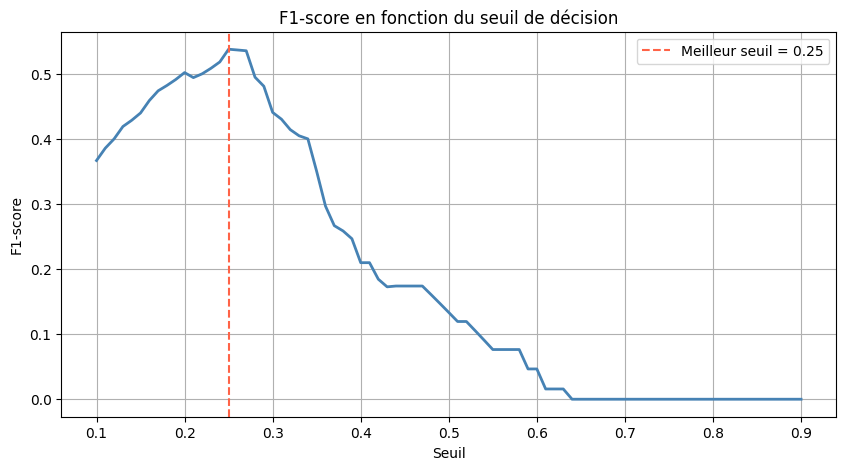

In [60]:
#  IMPORTATION DE LA MÉTRIQUE F1

# On importe f1_score depuis sklearn
# Cette fonction calcule le F1-score entre les vraies valeurs et les prédictions
from sklearn.metrics import f1_score

# RECHERCHE DU MEILLEUR SEUIL

# On initialise les variables pour stocker le meilleur seuil et le meilleur F1
meilleur_seuil = 0
meilleur_f1 = 0

# On affiche un titre pour la sortie
print("Recherche du meilleur seuil \n")

# On teste tous les seuils possibles entre 0.10 et 0.90
# [i/100 for i in range(10, 91)] génère la liste :
# [0.10, 0.11, 0.12, ..., 0.90]
# On teste 81 seuils différents pour être précis
for seuil in [i/100 for i in range(10, 91)]:

    # On applique le seuil actuel sur les probabilités
    # Si probabilité >= seuil → on prédit 1 (dangereuse)
    # Sinon → on prédit 0 (saine)
    y_pred_test = (y_proba >= seuil).astype(int)

    # On calcule le F1-score avec ce seuil
    # y_val : vraies valeurs, y_pred_test : prédictions avec ce seuil
    # zero_division=0 : évite une erreur si aucune zone dangereuse n'est prédite
    f1 = f1_score(y_val, y_pred_test, zero_division=0)

    # On affiche le F1-score pour ce seuil
    print(f"Seuil {seuil:.2f} → F1 : {f1:.2%}")

    # Si ce F1-score est meilleur que le précédent,
    # on met à jour le meilleur seuil et le meilleur F1
    if f1 > meilleur_f1:
        meilleur_f1 = f1
        meilleur_seuil = seuil

# On affiche le meilleur seuil trouvé
print(f"\n Meilleur seuil : {meilleur_seuil}")
print(f" Meilleur F1   : {meilleur_f1:.2%}")


# --- VISUALISATION ---

# On recrée la liste des F1-scores pour le graphique
seuils = [i/100 for i in range(10, 91)]
f1_scores = [f1_score(y_val, (y_proba >= s).astype(int),
             zero_division=0) for s in seuils]

# On trace la courbe F1-score en fonction du seuil
plt.figure(figsize=(10, 5))

# On dessine la courbe bleue
plt.plot(seuils, f1_scores, color='steelblue', linewidth=2)

# On marque le meilleur seuil avec un point rouge
plt.axvline(x=meilleur_seuil, color='tomato', linestyle='--',
            label=f'Meilleur seuil = {meilleur_seuil}')

# On ajoute les labels et le titre
plt.title("F1-score en fonction du seuil de décision")
plt.xlabel("Seuil")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

# **7. Prédictions finales et export CSV**

In [62]:
# PRÉPARATION DU FICHIER TEST

# On sélectionne uniquement les colonnes features dans le fichier test
# On supprime la colonne 'id' car ce n'est pas une feature
X_test = test.drop(columns=['id'], axis=1)

# On affiche la forme pour vérifier
# On doit avoir 2400 lignes et 20 colonnes
print(f"Fichier test prêt : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")


#  PRÉDICTION AVEC PROBABILITÉS

# On demande au modèle la probabilité que chaque zone soit dangereuse
# On garde uniquement la colonne 1 (probabilité d'être dangereuse) avec [:,1]
y_test_proba = model.predict_proba(X_test)[:, 1]


# --- APPLICATION DU MEILLEUR SEUIL (0.25) ---

# On applique le meilleur seuil trouvé automatiquement : 0.25
# Si la probabilité d'être dangereuse >= 25% → on prédit 1 (dangereuse)
# Sinon → on prédit 0 (saine)
# Ce seuil a donné le meilleur F1-score de 53.77%
seuil = meilleur_seuil  # = 0.25
y_test_pred = (y_test_proba >= seuil).astype(int)

# On affiche un aperçu des prédictions
print(f"\n Aperçu des prédictions : {y_test_pred[:10]}")
print(f" Nombre de zones saines     : {(y_test_pred == 0).sum()}")
print(f" Nombre de zones dangereuses: {(y_test_pred == 1).sum()}")


#  CRÉATION DU FICHIER CSV FINAL

# On crée un nouveau tableau avec deux colonnes :
# - id : l'identifiant de chaque zone (issu du fichier test)
# - target : la prédiction du modèle (0 ou 1)
resultats = pd.DataFrame({
    'id': test['id'],
    'target': y_test_pred
})

# On affiche les premières lignes pour vérifier
print("\n Aperçu du fichier final ")
print(resultats.head(10))

# On exporte le tableau dans un fichier CSV
# index=False : on ne veut pas d'index numérique en plus dans le fichier
resultats.to_csv('predictions_finales.csv', index=False)

# On confirme que le fichier a bien été créé
print("\n Fichier 'predictions_finales.csv' créé avec succès !")

Fichier test prêt : 2400 lignes, 20 colonnes

 Aperçu des prédictions : [0 0 0 0 1 0 0 0 0 0]
 Nombre de zones saines     : 2192
 Nombre de zones dangereuses: 208

 Aperçu du fichier final 
     id  target
0  2935       0
1  3298       0
2  6683       0
3  5441       0
4  3945       1
5  7200       0
6  6524       0
7  5219       0
8  4558       0
9  4493       0

 Fichier 'predictions_finales.csv' créé avec succès !
